In [1]:
import matplotlib.pyplot as plt 
import xarray as xr
import numpy as np 
import occ

In [7]:
%matplotlib inline                           
%config InlineBackend.figure_format='retina' 
plt.rcParams['figure.figsize'] = 8,4  
plt.rcParams['figure.dpi'] = 300

In [8]:
SST_OISST = xr.open_dataset('sst.oisst.mon.ltm.1991-2020.nc',use_cftime=True)

/var/folders/y3/jjb7h7fd4mg_yy8nsvfhwzym0000gn/T/ipykernel_84260/187261218.py:1: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  SST_OISST = xr.open_dataset('sst.oisst.mon.ltm.1991-2020.nc',use_cftime=True)


In [9]:
SST = SST_OISST.sst

In [10]:
dsout = occ.drift.detrend(SST, 'sst')
dsout

<xarray.Dataset> Size: 17MB
Dimensions:        (lat: 180, lon: 360, time: 12)
Coordinates:
  * lat            (lat) float32 720B -89.5 -88.5 -87.5 -86.5 ... 87.5 88.5 89.5
  * lon            (lon) float32 1kB 0.0 1.0 2.0 3.0 ... 356.0 357.0 358.0 359.0
  * time           (time) object 96B 1991-01-01 00:00:00 ... 1991-12-01 00:00:00
Data variables:
    sst_slope      (lat, lon) float64 518kB 0.0 0.0 0.0 ... 0.0171 0.01722
    sst_intercept  (lat, lon) float64 518kB nan nan nan ... -1.706 -1.707 -1.707
    sst_dedrifted  (time, lat, lon) float64 6MB nan nan nan ... -1.916 -1.918
    sst_trend      (lat, lon, time) float64 6MB nan nan nan ... -1.534 -1.517
    sst_raw        (time, lat, lon) float32 3MB nan nan nan ... -1.728 -1.728

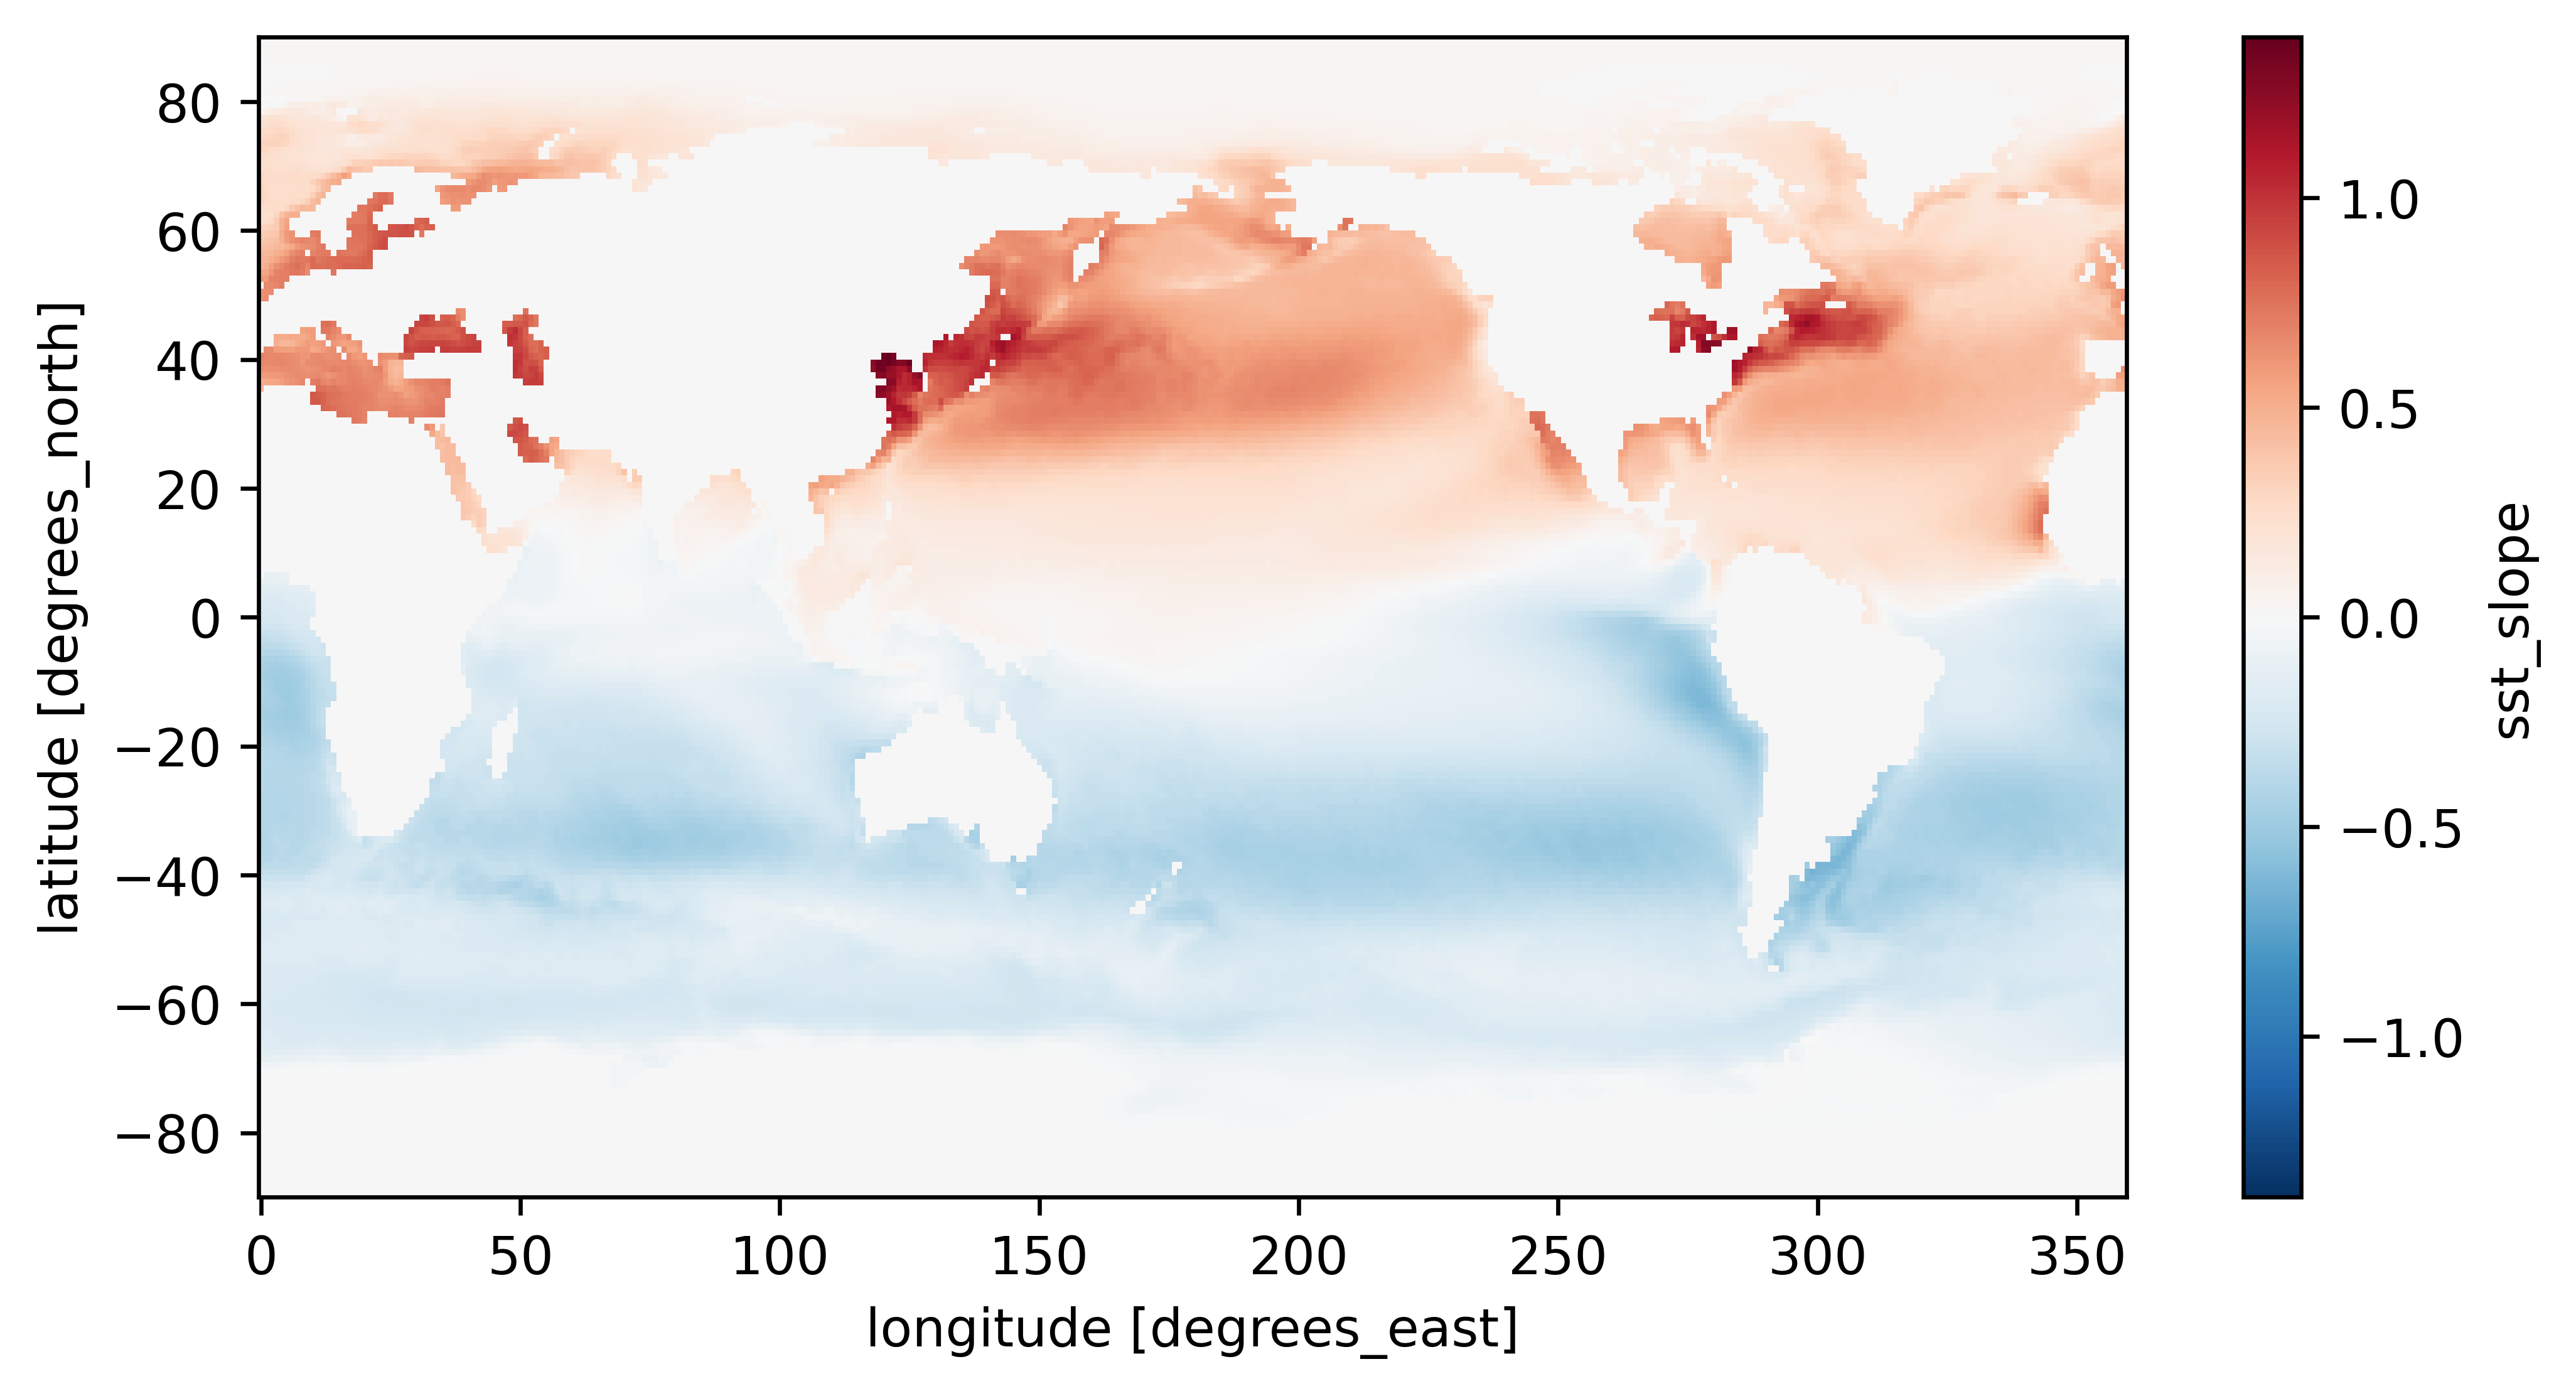

In [11]:
dsout.sst_slope.plot()